### 1. Tensor Manipulation

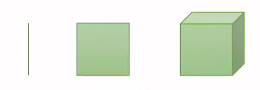

- 1차원: Vector, 2차원: Matrix(행렬)...
- Tensor : 숫자를 여러 차원으로 저장하는 자료구조, 0차원 Tensor : Scalar, 1차원 Tensor : Matrix

- *다른 Device(GPU,CPU)끼리는 Tensor 계산이 불가능하다.

- Pytorch는 모든 딥러닝 연산을 Tensor를 기준으로 설계했기 때문에,  PyTorch가 제공하는 대부분의 함수는 Tensor를 입력으로 받는다.

In [8]:
import torch
import numpy as np

t = torch.FloatTensor([[1., 2., 3.],[4., 5., 6.],[7., 8., 9.],[10., 11., 12]])
print(t)
print(t.dim())
print(t.size())
print(t[:, 1])
print(t[:, 1].size())



tensor([[ 1.,  2.,  3.],
        [ 4.,  5.,  6.],
        [ 7.,  8.,  9.],
        [10., 11., 12.]])
2
torch.Size([4, 3])
tensor([ 2.,  5.,  8., 11.])
torch.Size([4])


#### Broadcasting: 덧셈, 뺄셈, 곱하기 등 연산을 할 때 크기가 맞아야 하지만 torch에서는 맞지 않아도 크기를 알아서 맞춰서 계산해준다.

In [ ]:
import torch

# Same shape
m1 = torch.FloatTensor([[3, 3]])
m2 = torch.FloatTensor([[2, 2]])
print(m1 + m2)

# Vector + scalar
m3 = torch.FloatTensor([[1, 2]])
m4 = torch.FloatTensor([3])
print(m3 + m4)

# 2 * 1 Vector + 1 * 2 Vector
m5 = torch.FloatTensor([[1, 2]])
m6 = torch.FloatTensor([[3], [4]])
print(m5 + m6)

tensor([[5., 5.]])
tensor([[4., 5.]])
tensor([[4., 5.],
        [5., 6.]])


In [ ]:
import torch 
# mean을 사용할 때 정수는 사용할 수 없다.
t = torch.LongTensor([1, 2])

try:
    print(t.mean())
except Exception as exc:
    print(exc)

t1 = torch.FloatTensor([[1, 2], [3, 4]])
print(t1)

print(t1.mean())
print(t1.mean(dim = 0)) # 열끼리 평균을 해서 행을 없앤다. ((2, 2)에서 0번째이기 때문에)
print(t1.mean(dim = 1)) # 행끼리 평균
print(t1.mean(dim = -1)) # 행끼리 평균




mean(): could not infer output dtype. Input dtype must be either a floating point or complex dtype. Got: Long
tensor([[1., 2.],
        [3., 4.]])
tensor(2.5000)
tensor([2., 3.])
tensor([1.5000, 3.5000])
tensor([1.5000, 3.5000])


In [27]:
import torch

t = torch.FloatTensor([[1, 2], [3, 4]])
print(t)

print(t.sum())
print(t.sum(dim = 0))
print(t.sum(dim = 1))


tensor([[1., 2.],
        [3., 4.]])
tensor(10.)
tensor([4., 6.])
tensor([3., 7.])


#### View (Reshape)
###### 모양을 원하는대로 다시 잡아줌.

In [43]:
import numpy as np
import torch

t = np.array([[[0, 1, 2],
               [3, 4, 5]], 


               [[6, 7, 8], 
                [9, 10, 11]]])
ft = torch.FloatTensor(t)
print(ft)
print(ft.shape)


print(ft.view([-1, 3]))
print(ft.view([-1, 3]).shape)

print(ft.view([-1, 1, 3]))
print(ft.view([-1, 1, 3]).shape)

tensor([[[ 0.,  1.,  2.],
         [ 3.,  4.,  5.]],

        [[ 6.,  7.,  8.],
         [ 9., 10., 11.]]])
torch.Size([2, 2, 3])
tensor([[ 0.,  1.,  2.],
        [ 3.,  4.,  5.],
        [ 6.,  7.,  8.],
        [ 9., 10., 11.]])
torch.Size([4, 3])
tensor([[[ 0.,  1.,  2.]],

        [[ 3.,  4.,  5.]],

        [[ 6.,  7.,  8.]],

        [[ 9., 10., 11.]]])
torch.Size([4, 1, 3])


#### Squeeze
###### 크기가 1인 차원을 제거하는 함수다.

In [46]:
import torch

ft = torch.FloatTensor([[0], [1], [2]])
print(ft)
print(ft.shape)

print(ft.squeeze())
print(ft.squeeze().shape)

tensor([[0.],
        [1.],
        [2.]])
torch.Size([3, 1])
tensor([0., 1., 2.])
torch.Size([3])


#### Unsqueeze
###### 크기가 1인 차원을 늘려준다.(무슨 차원인지는 우리가 지정)

In [54]:
import torch

ft = torch.Tensor([0, 1, 2])
print(ft.shape)
print("------")
print(ft.unsqueeze(0)) # 0차원에 1을 넣는다.
print(ft.unsqueeze(0).shape)

print("--------")
print(ft.view(-1,3))
print(ft.view(-1,3).shape)

print("----------")
print(ft.unsqueeze(1))
print(ft.unsqueeze(1).shape)

torch.Size([3])
------
tensor([[0., 1., 2.]])
torch.Size([1, 3])
--------
tensor([[0., 1., 2.]])
torch.Size([1, 3])
----------
tensor([[0.],
        [1.],
        [2.]])
torch.Size([3, 1])


### Concatenate
###### 행렬들 붙히기



In [55]:
import torch

x = torch.FloatTensor([[1, 2], [3, 4]])
y = torch.FloatTensor([[5, 6], [7, 8]])

print(torch.cat([x, y],dim = 0))
print(torch.cat([x, y], dim = 1))

tensor([[1., 2.],
        [3., 4.],
        [5., 6.],
        [7., 8.]])
tensor([[1., 2., 5., 6.],
        [3., 4., 7., 8.]])


### Stacking
###### 행렬들 쌓아주기


In [58]:
import torch

x = torch.FloatTensor([1, 4])
y = torch.FloatTensor([2, 5])
z = torch.FloatTensor([3, 6])

print(torch.stack([x, y, z]))
print(torch.stack([x, y, z], dim = 1))

print(torch.cat([x.unsqueeze(0), y.unsqueeze(0), z.unsqueeze(0)], dim = 0))

tensor([[1., 4.],
        [2., 5.],
        [3., 6.]])
tensor([[1., 2., 3.],
        [4., 5., 6.]])
tensor([[1., 4.],
        [2., 5.],
        [3., 6.]])


### Ones and Zeros
###### 행렬 모양은 똑같이 하고 1이나 0으로 채우기

In [60]:
import torch

x = torch.FloatTensor([[0, 1, 2], [2, 1, 0]])
print(x)

print(torch.ones_like(x))
print(torch.zeros_like(x))

tensor([[0., 1., 2.],
        [2., 1., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[0., 0., 0.],
        [0., 0., 0.]])


### In-place Operation
###### _(언더스코어)가 붙으면 대부분 In-place 연산이고 새로운 Tensor를 만드는 것이 아니라 기존의 Tensor를 직접 계산한다.


In [62]:
import torch 

x = torch.FloatTensor([[1, 2], [3, 4]])

print(x.mul(2.))
print(x)
print(x.mul_(2.)) # x에 그대로 계산한다.
print(x)

tensor([[2., 4.],
        [6., 8.]])
tensor([[1., 2.],
        [3., 4.]])
tensor([[2., 4.],
        [6., 8.]])
tensor([[2., 4.],
        [6., 8.]])
